# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
plans.head()# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(f'cantidad de valroes nulos por columna tabla  users_latam\n')
print(users.isna().sum()) # Cantidad de valores nulos)
print(f'\nProporción de valroes nulos por columna\n')
print(users.isna().mean()) # Proporción de valores nulos)

cantidad de valroes nulos por columna tabla  users_latam

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valroes nulos por columna

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(f'cantidad de valroes nulos por columna tabla  usage\n')
print(usage.isna().sum()) # Cantidad de valores nulos)
print(f'\nProporción de valroes nulos por columna\n')
print(usage.isna().mean()) # Proporción de valores nulos)

cantidad de valroes nulos por columna tabla  usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valroes nulos por columna

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Se puede apreciar que la tabla *users_latam* hay faltantes en los registros de las columnas *city* 469 y *churn_date* 3534. Se identificaron registros en *city* con caracteres fuera de lo normal como "?".   
* Para *city* se debe realizar una limpieza de datos agregando nulos reales (NaN) y despues    imputar con "unknow" para no afectar ni perder los registros.   
* Para *churn_date* se deben imputar los datos como  "activo" o "usuario_activo" ya que el registro indica a los usuarios que no han dejado de usar el servicio. 


La tabla *usage* posee falantes en las columnas *date*, *duration* y *length* las cuales tiene un 0.12% , 55.19% y 44.74% respectivamente.    
* Para *date* eliminar registros con nulos ya que son tan pocos que realmente no afectan el analisis.
* Para el caso de *duration* y *lenght* los nulos se imputaran con 0 por la naturaleza de los datos (mensajes vs llamadas). Una llamada no puede tener longitud y un mensaje no puede tener duración. 


💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 


 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
users.describe()# explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` funciona como columna para identificadores el numero de registro se ve en orden ya que los valores min y max coniciden con el numero total de registros  
- La columna `age` hay errores de captura en esta columna ya que se encuentra un valor min de -999 y esta es una edad imposible esto afectando directamente el analisis.
  

In [13]:
usage.describe()# explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`son datos que se usan como identificadores no se aprecia nada anormal valores min y max coniciden con el total de registros en count 
- Las columnas `duration` y `lenght` ambas poseen un valor min de 0, esto no es un error devido a la naturaleza de los datos ya que ambos miden datos que pueden llevar 0. (En el caso de `duration` que mide el tiempo en llamadas al presentarse un registro que se trate de un mensaje este no podra registrar tiempo de duración pero si registrara datos en `lenght` que guarda la longitud de texto de cada mensaje.)

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` se puede apreciar que hay un total de 3431 rigistros que se han detectados como no nulos, pero como se vio anterior mente hay que hacer limpieza de datos y estandarizar los *?* detectados para idetificar la cantidad de nulos reales. Son 7 valores(ciudades) distintos de los cuales el dato que tiene mas frecuencia es Bogota con 808 capturas.
- La columna `plan` se puede apreciar que todo esta en orde, son 2 valores unicos *premium* y *basico*  de los ocuales se nos indica que el "plan" *Basico* es el que mas frecuencia tiene con una repeticion de 2595 registros.

In [15]:
# explorar columna categórica de usage
usage['type'].describe()# completa el código


count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` tiene 4000 registros esto nos indica que no cuenta con valores nulos, contiene 2 registros unicos, *text* y *call*.  de los cuales *text* es el que cuenta con mayor frecuencia de captura.  


---
✍️ **Comentario**: Con la exploración realizada anterior mente se puede apreciar que hay algunas *columnas* que contienen valores nulos y otras que hay datos invalidos para el analizis. `city` posee valores invalidos detectados **"?"** y a su vez tambien tiene nulos, hay que realizar los procedimientos pertinentes para la limpieza y estandarización de datos, recomiendo remplazar los valores **"?"** con **"unknow"** usando el metodo `.remplace(valor_viejo, valor_nuevo)` 

Para los valores nulos de las columnas `lenght` y `duration` remplazar los **Nan** por **0** para que los datos esten en orden acorde lo que se esta midiendo. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors='coerce') # completa el código
print(users['reg_date'].dtype)
print(users['reg_date'].head())

datetime64[ns]
0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]


In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce') # completa el código
print(usage['date'].dtype)
print(usage['date'].head())# completa el código

datetime64[ns]
0   2024-01-01 00:00:00.000000000
1   2024-01-01 00:06:30.969774244
2   2024-01-01 00:13:01.939548488
3   2024-01-01 00:19:32.909322733
4   2024-01-01 00:26:03.879096977
Name: date, dtype: datetime64[ns]


In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se puede apreciar que los años que abarcan los registros son del 2022 en adelante pero hay algunos pocos registros con el año 2026, esto ultimo peude ser posiblmente un error de captura tratando de hacer referencia al 2024 teniendo un "error de dedo" y marcando 6 en lugar de 4. 

Para los datos del 2026 al presentar solo el 1% de los datos totales registrados se podria optar por eliminar o marcar como nulos(NaN) esos registros y no se presentaria una alteración relevante en el analizis ya que solo son 40 registros. 

Se puede apreciar que hay un retención de usuario muy estable y un crecimiento lento pero constante. Aunque si solo se busca tomar en cuenta fechas del 2024 como datos validos para el analizis se tendranque realizar filtros de DataFrame para que los datos que no son requeridos queden fuera del rango durante el analizis 

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()


2024.0    39950
Name: date, dtype: int64

En `date`, Se aprecia claramente que hay 50 datos nulos, de igual manera se pueden eliminar o imputar los datos con la mediana de las fechas ya que todas son del año 2024.  

Basaremos el análisis en estas fechas.

✍️ **Comentario**: En la columna reg_date se pueden apreciar fechas que no concuerdan con lo que se solicita, algunas son mas antiguas y se encuentran pocos registros con fechas imposibles, para estos ultimos recomiendo eliminarlos o imputarlos con el año 2024 ya que claramente fueron error de captura. 

para usage se visualiza que la mayoria de los registros estan en orden y solo el 1.25% de los registros son nulos, de igual forma se podrian imputar con el año 2024 o eliminarlos ya que igual al ser un valor relativamnete bajo no afectaria en lo practico

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
# Reemplazar ? por NA en city
# funcion para estandarizar sentinels
def estandarización_sentinels(df,numeric_cols,text_cols):
    numeric_sentinels = [-999, 999]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].replace(numeric_sentinels, df[col].median())
    text_sentinels = ['?']
    for col in text_cols:
        df[col] = df[col].replace(text_sentinels, pd.NA)
    return df


In [21]:
#columnas ah corregir
años = ["age"] 
ciudades = ['city']
#aplicacion de la función y  
estandarización_sentinels(users,años,ciudades)
users['age'].describe()


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Verificar cambios de city
users['city'].head()

0    Medellín
1        <NA>
2        CDMX
3      Bogotá
4         GDL
Name: city, dtype: object

In [23]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
#filtro de datos para ver mensajes y llamadas
mensajes = usage[usage['type'] == 'text']
llamadas = usage[usage['type'] == 'call']
#conteo de nulos 
mensajes_nulos = mensajes['duration'].isna().sum()
llamadas_nulos = llamadas['duration'].isna().sum()
print(f'conteo de nulos en columna duration por tipo')
print(f'Nulos en mensajes: {mensajes_nulos}')
print(f'Nulos en llamadas: {llamadas_nulos}')

conteo de nulos en columna duration por tipo
Nulos en mensajes: 22076
Nulos en llamadas: 0


In [25]:
# Verificación MAR en usage (Missing At Random) para length
print(f'conteo de nulos en lenght por tipo')
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))

conteo de nulos en lenght por tipo
type
call    17896
text        0
Name: length, dtype: int64


Con lo visto anterior mente claramente son datos MAR, ya que los nulos no son causados aleatoriamente hay una relación entre las columnas y datos. Por ese motivo se dejaran los datos como nulos. 

Como dicho anteiror mente cuando **tipe** sea **call** *length* quedara en NaN y cuando sea **text** *duration* pasara a quedar en 0 o NaN

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).rename(columns={  # Renombrar Columnas
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'})

# observar resultado.reset_index()
usage_agg.head(3)


,cant_mensajes,cant_llamadas,cant_minutos_llamada
user_id,,,
10000,7,3,23.70
10001,5,10,33.18
10002,5,2,10.74


In [27]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile =  users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

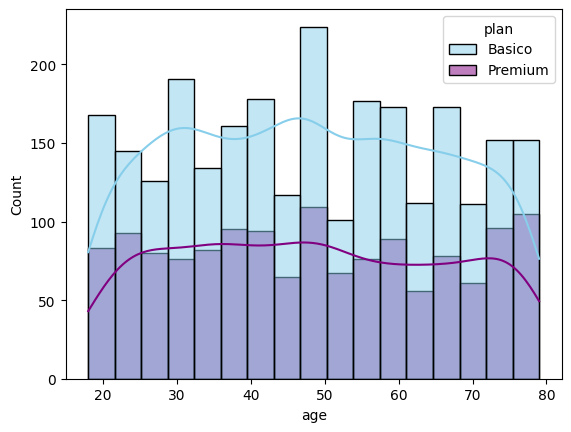

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'purple'], kde=True)
plt.show()

💡Insights: 
- La distribución de la variable age es uniforme, lo que indica que la empresa abarca de manera equitativa todas las edades (entre 18 y 80 años aproximadamente). A simple vista, se observa que el plan Básico posee una mayor proporción de usuarios en todos los rangos de edad. Además, no existe algún patrón que relacione la edad con la preferencia del plan, ya que las distribuciones de ambos planes tienen una forma casi idéntica.

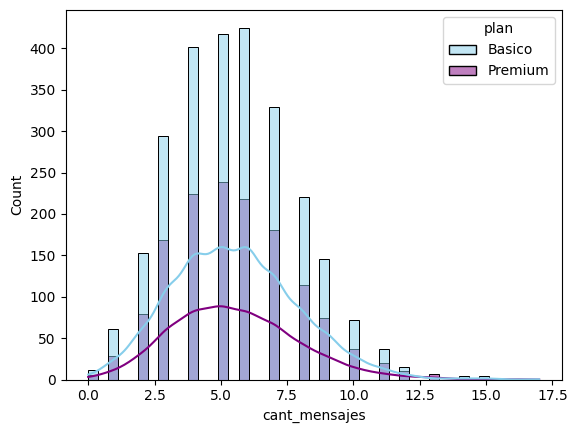

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'purple'], kde=True)
plt.show()

💡Insights: 
- cant_mensajes presenta una distribución con un ligero sesgo a la derecha. Aunque la mayoría de los usuarios se concentra en el rango de 4 a 6 mensajes, existe una minoría de usuarios que consume un volumen significativamente mayor, llegando hasta los 17 mensajes. No obstante, el comportamiento entre planes sigue siendo muy similar, con el plan Básico manteniendo la mayor frecuencia en todos los puntos.

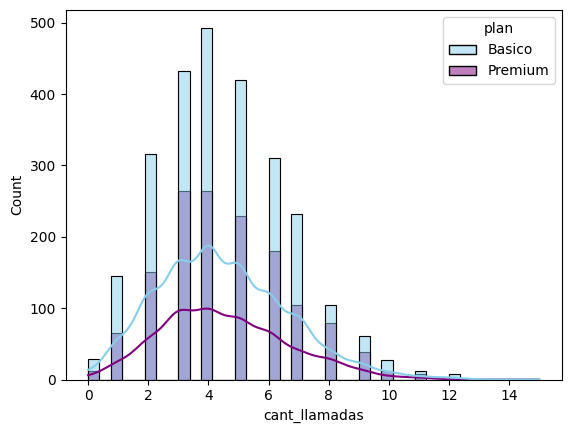

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'purple'], kde=True)
plt.show()

💡Insights: 
-  Al igual que cant_mensajes, cant_llamadas presenta una distribución con un ligero sesgo a la derecha. Aunque la mayoría de los usuarios se concentra en el rango de 3 a 5 llamadas, existe una minoría de usuarios que consume un volumen significativamente mayor, llegando hasta las 14 llamadas. No obstante, el comportamiento entre planes sigue siendo muy similar, con el plan Básico manteniendo la mayor frecuencia en todos los puntos.


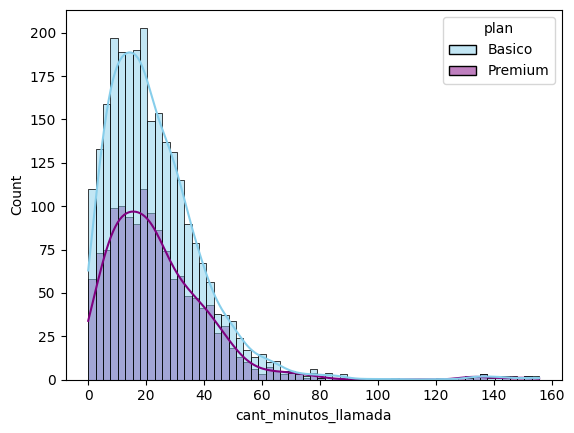

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'purple'], kde=True)
plt.show()

💡Insights: 
- La distribución de cant_minutos_llamada muestra un sesgo a la derecha pronunciado. Se aprecia que, aunque el plan Básico posee más usuarios, estos tienden a concentrarse en consumos menores. En contraste, el plan Premium muestra una dispersión mayor, lo que sugiere que sus usuarios realizan llamadas de mayor duración con más frecuencia

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

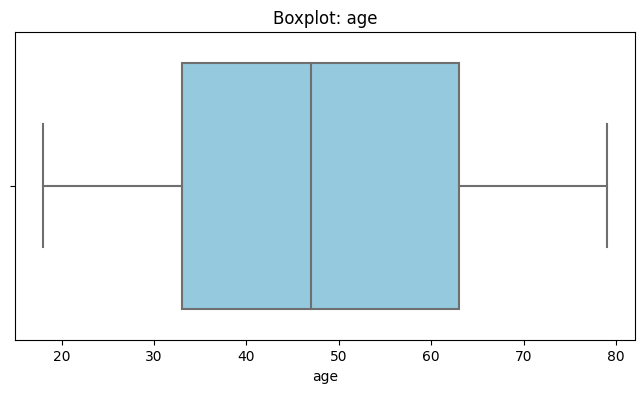

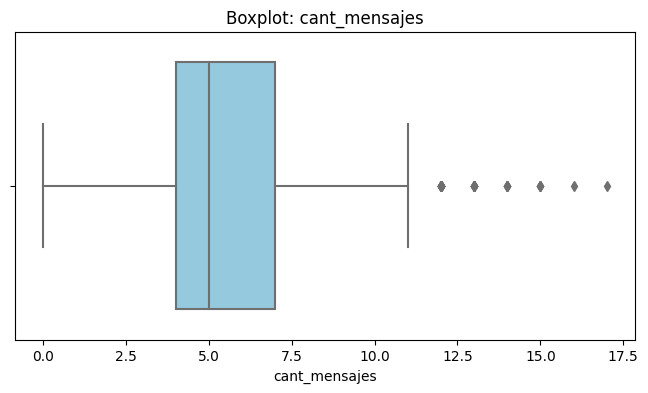

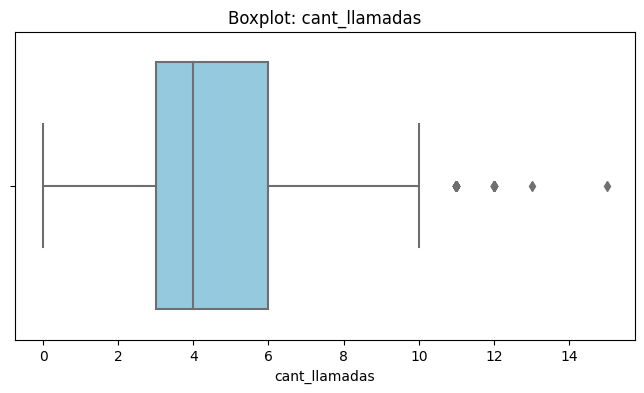

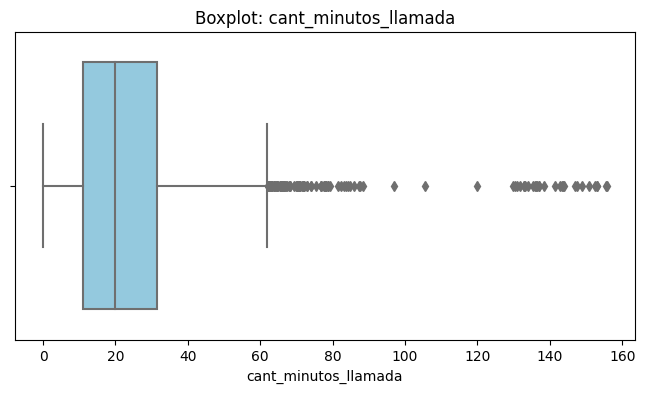

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col, hue='plan', palette=['skyblue', 'green'])
    plt.title(f'Boxplot: {col}') # Título dinámico según la columna
    plt.show()

💡Insights: 
- Age: No se peresentan outliers como se puede apreciar en el Boxplot
- cant_mensajes: Si se llegan a presentar pero son pocos los outliers que se pueden apreciar en el grafico que son entre 11 y 17 mensajes. 
- cant_llamadas: Sí se presentan outliers aun que siguen siendo pocos los registros fuera de los rangos normales, en llamadas los outliers rondan entre los 11 y 17 llamadas
- cant_minutos_llamada: Sí se presentan outliers aunque en esta ocación si son una cantidad considerable de registros fuera del rango. 

In [35]:
# Calcular límites con el método IQR
columnas_limites = columnas_numericas
# Bucle para calcular los límites del Método IQR
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_superior = Q3 + 1.5 * IQR
    print(f"Columna {col}: El límite superior para detectar outliers es {limite_superior:.2f}")




Columna age: El límite superior para detectar outliers es 108.00
Columna cant_mensajes: El límite superior para detectar outliers es 11.50
Columna cant_llamadas: El límite superior para detectar outliers es 10.50
Columna cant_minutos_llamada: El límite superior para detectar outliers es 61.86


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Mantener outliers.
- cant_llamadas: mantener o no outliers, porqué? Mantener outliers.
- cant_minutos_llamada: mantener o no outliers, porqué? Mantener outliers.

En todos los casos los datos no son errores son usuarios de alto valor que deben mantenerse pero se recomienda evaluarlos de manera independiente fuera del conjunto de usuarios que tienen un uso dentro de los cuartiles.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [38]:
user_profile = user_profile.astype({
    'cant_mensajes': 'Int64',
    'cant_llamadas': 'Int64',
    'age': 'Int64'
})
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


In [42]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Uso alto'
user_profile.loc[(user_profile['cant_mensajes'] < 10) & (user_profile['cant_llamadas'] < 10), 'grupo_uso' ] = 'Uso medio'
user_profile.loc[(user_profile['cant_mensajes'] < 5) & (user_profile['cant_llamadas'] < 5), 'grupo_uso' ] = 'Uso bajo'



In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Uso alto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Uso alto
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Uso bajo


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [44]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'
user_profile.loc[(user_profile['age'] < 60), 'grupo_edad'] = 'Adulto'
user_profile.loc[(user_profile['age'] < 30), 'grupo_edad'] = 'Joven'


In [49]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Uso alto,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Uso alto,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Uso bajo,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

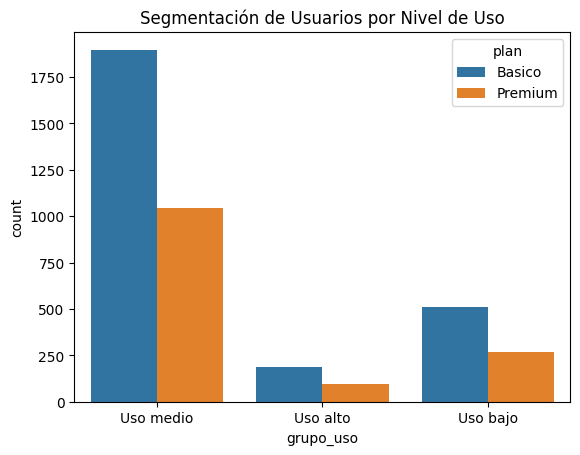

In [46]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso', hue='plan' )
plt.title('Segmentación de Usuarios por Nivel de Uso')
plt.show()


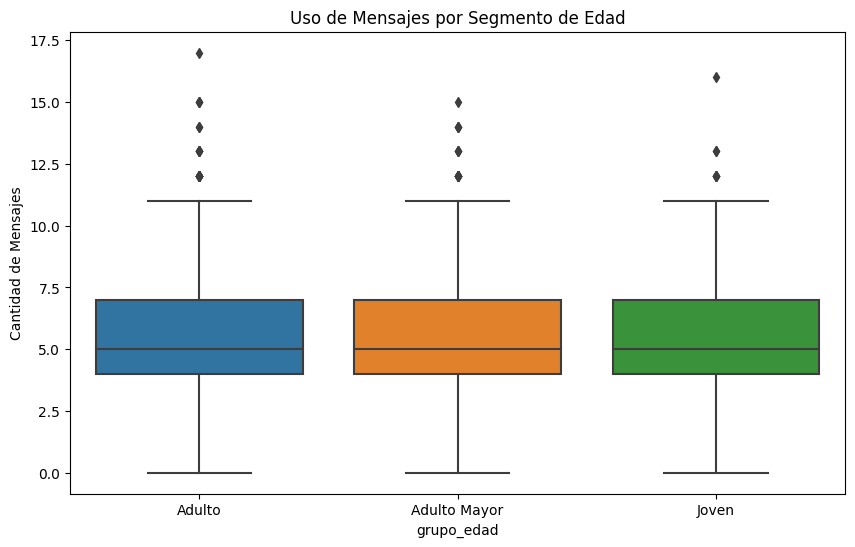

In [79]:


plt.figure(figsize=(10,6))
sns.boxplot(data=user_profile, x='grupo_edad', y='cant_mensajes')
plt.title('Uso de Mensajes por Segmento de Edad')
plt.ylabel('Cantidad de Mensajes')
plt.show()



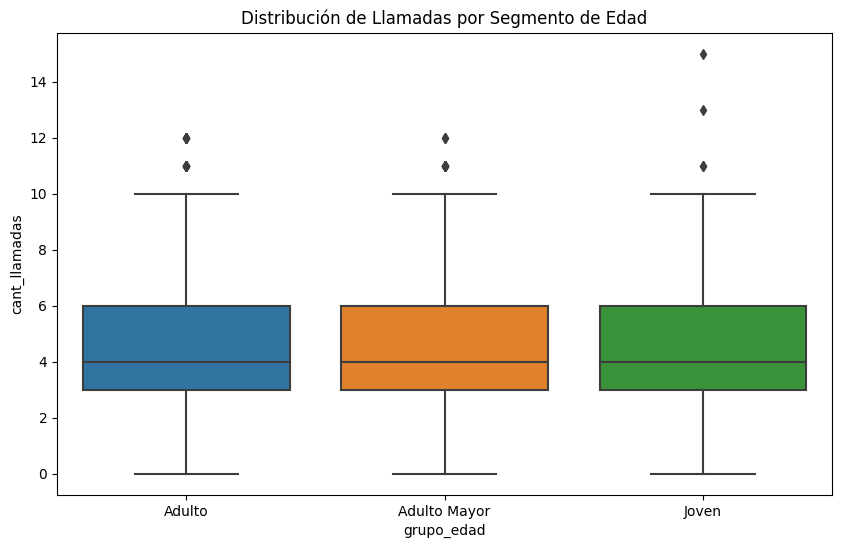

In [88]:
# Opción 2: Boxplot para ver distribución
plt.figure(figsize=(10,6))
sns.boxplot(data=user_profile, x='grupo_edad', y='cant_llamadas')
plt.title('Distribución de Llamadas por Segmento de Edad')
plt.show()

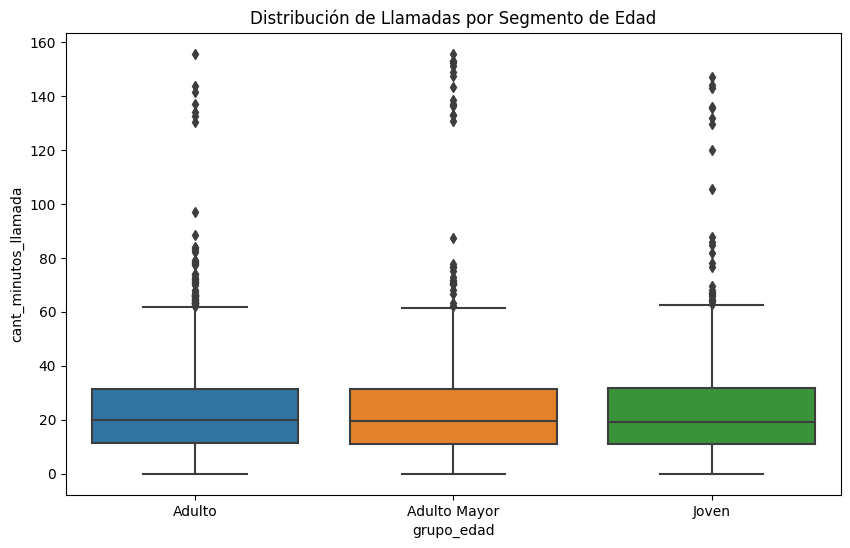

In [90]:
plt.figure(figsize=(10,6))
sns.boxplot(data=user_profile, x='grupo_edad', y='cant_minutos_llamada')
plt.title('Distribución de Llamadas por Segmento de Edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
 - Valores nulos o ausencias en *users_latam* en las columnas *city* y *churn_date*
 - En usage, date, duration y length fallas menores como, fechas fuera del rango o imposibles, nulos en las columnas duration y lenght.
 - Valores invaliodos o sentinels en:
       - age: -999
       - city: ?
   
- los valores duration y lenght no eran errores sino que esos nulos dependian directamaente del tipo de servicio brindado
- Se realizo la técnica de IQR sobre *cant_minutos_llamada*, *cant_mensajes* y *cant_llamadas*se determinaron los valores para segmentar por edad y consumo a los usuarios 



🔍 **Segmentos por Edad**
Los datos fueron segmentados por edad en *Joven*, *Adulto* y *Adulto Mayor*
 -Jove si el usuario tiene una edad menor a 30 años
 -Adulto si el usuario cuenta con una edad mayor a 30 pero menor a 60 años
 -Adulto mayor si el usuario cuenta con una edad mayor a 60 años. 


📊 **Segmentos por Nivel de Uso**
Para la segmentación por Nivel de uso, se realizo el conteo de mensajes y llamadas que realiza cada usuario para segmentarlos en "*uso bajo*" , "*uso medio*" y "*uso alto*" se siguieron las siguientes condiciones:
- uso bajo si el usuario a utilizado menos de 5 mensajes y realizado menos de 5 llamadas
- uso mendio si el usuario a utilizado menos de 10 mensajes y realizado menos de 10 llamadas
- uso alto si el usuario a utilizado almenos mas de 10 mensajes o llamadas. 

➡️ Esto sugiere que ...
-Los outliers detectados no son fallas de sistma ni de captura, sino  comportamientos reales que revelan perfiles especificos y hay que poner un foco especial para hacer un analisis aparte de su comportamiento. 

💡 **Recomendaciones**
- De manera general ampliar la oferta de planes para poder retener y mantener a los usuarios con una mejor satisfacción con el servicio. 
- Al observar los grupos se mostró que la mayoria de usuarios se concentran en el segmento de uso medio. Esto abre la oportunidad de poder crear un plan intermedio el cual permita capturar y retener a los usuarios altos que no necesitan los 600 min del plan premium pero que no pueden contratar el plan basico ya que los 100 min no son suficientes. Se tiene una diferencia muy grande entre los 100 min del plan basico a los 600 min del plan premium y esto es grave ya que puede hacer que usuarios premium deserten buscando un plan intermedio con la competencia.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`